<font color="#de3023"><h1><b>REMINDER MAKE A COPY OF THIS NOTEBOOK, DO NOT EDIT</b></h1></font>

# Goals
In this colab you will:
* Normalize and clean up your data.
* Explore your data using unsupervised learning methods.
* Build a model to predict crop yield from bacterial composition using a decision tree.
* Visualize and interpret a decision tree.

In [ ]:
#@title ###Setup notebook.

!gdown --id 1DgOZ56YruuUmHRD7hZNJNM39mlbRGApp # sample metadata
!gdown --id 1R4Nv1SY4zn_Z3wnZuJcCHKI6yVPGGgGZ # bacteria counts lognorm

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

metadata = pd.read_table('sample_metadata.tsv')
metadata.index = ['farm_%i' % i for i in range(len(metadata))]

bacteria_counts_lognorm = pd.read_csv('bacteria_counts_lognorm.csv', index_col=0)


/usr/local/lib/python3.7/dist-packages/gdown/cli.py:131: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  category=FutureWarning,
Downloading...
From: https://drive.google.com/uc?id=1DgOZ56YruuUmHRD7hZNJNM39mlbRGApp
To: /content/sample_metadata.tsv
100% 64.3k/64.3k [00:00<00:00, 16.2MB/s]
/usr/local/lib/python3.7/dist-packages/gdown/cli.py:131: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  category=FutureWarning,
Downloading...
From: https://drive.google.com/uc?id=1R4Nv1SY4zn_Z3wnZuJcCHKI6yVPGGgGZ
To: /content/bacteria_counts_lognorm.csv
100% 7.44M/7.44M [00:00<00:00, 106MB/s]


# A Starting Model

Great! Now that we've cleaned up and explored our data a bit, it's time to build our first model. We are going to use something called a decision tree regression model (using the ```DecisionTreeRegressor``` scikit-learn model). You can check out the documentation on [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html), and the schematic below described what a trained decision tree regression model looks like. Note that the model initialization, training, and testing follows the same framework as all of the other models we've trained. You've got this!


<img src = "https://i.ibb.co/ct3Cn6K/decision-tree-regressor.jpg" height=400/>

####**Exercise: Just to review, in our model to predict crop-yield from bacterial composition of soil, what will we be using as *features* (i.e. X data or independent variable)  and *labels* (i.e. Y data or dependent variable)?**


In [ ]:
_features_ = 'bacterial composition' #@param {type:"string"}
_labels_ = 'crop yield' #@param {type:"string"}


####**Exercise: Fill out the code below to split your data into testing and training, train your ```DecisionTreeRegressor``` model, and make predictions on your test data.** Don't worry about computing model accuracy just yet.

In [ ]:
# We helped you define your X and y data here.
X = bacteria_counts_lognorm
y = metadata['crop_yield']

# Next, split your data into testing and training.
X_train, X_test, y_train, y_test = train_test_split(X, y)

# Now, initialize your model (just use the default settings for now!)
model = DecisionTreeRegressor()
# Train your model with the training data. Hint: use the model.fit() function
model.fit(X_train, y_train)


DecisionTreeRegressor()

#### **Exericse: Now, make predictions on your testing dataset so that we can take a look at model performance. Don't compute accuracy just yet though!**

In [ ]:
# Make predictions on your test data. Hint: use the model.predict() function.
preds = model.predict(X_test)  ## FILL ME IN ###

#### **Exercise: Run the code below to visualize the performance of your model, and discuss how you feel your model performed.**

**(Optional):** Can you plot your model's line of best fit to see how closely
predictions matched yields?


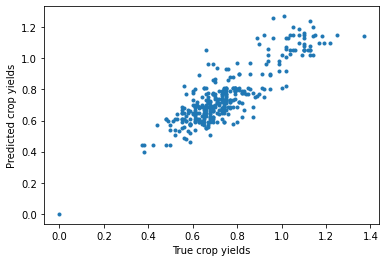

In [ ]:
plt.plot(y_test, preds, '.')
plt.xlabel('True crop yields')
plt.ylabel('Predicted crop yields')
plt.show()

**Discuss: Why can't we compute an 'accuracy score' for this model like we did for many of the models we worked on last week? What are some other ways we could evaluate how well our model performed?** (Stay tuned for the next notebook!)

# Visualizing and Interpreting Decision Trees

Decision trees are really great models because they can be easily visualized and interpreted. ***Interpreting a model*** means understanding why the model is making its decisons/predictions. Models that are tricky to interpret are sometimes called ***black-box models***, because it's tough to really grasp what the algorithm inside is doing. Some people consider neural networks somewhat of a black-box and a major field of AI research is finding ways to interpret neural networks.

####**Exercise: What are some reasons that machine learning researchers (and policy makers for that matter) are so concerned about model interpretability?**



In [ ]:
_1_ = '' #@param {type:"string"}
_2_ = '' #@param {type:"string"}



## Visualization
One way we can help understand what a decision tree is doing under the hood is by visualization. We can visualize the decision tree our model learned using some cool graphics libraries in python. Let's try this out.

### A Small Toy Model


####**Exercise: Let's quickly train a very small model using only 3 features so we can practice visualizing a decision tree. Run the following code to train a 3-feature model.**

In [ ]:
# Now, initialize your model (just use the default settings for now!)
small_model = DecisionTreeRegressor(max_depth=3, max_leaf_nodes=2)

# Train your model with the training data, using only three features.
small_model.fit(X_train[['Actinocorallia', 'Clostridium sensu stricto 10', 'Blastocatellaceae']], y_train)


DecisionTreeRegressor(max_depth=3, max_leaf_nodes=2)

####**Exercise: Now run the following code to visualize your model.**

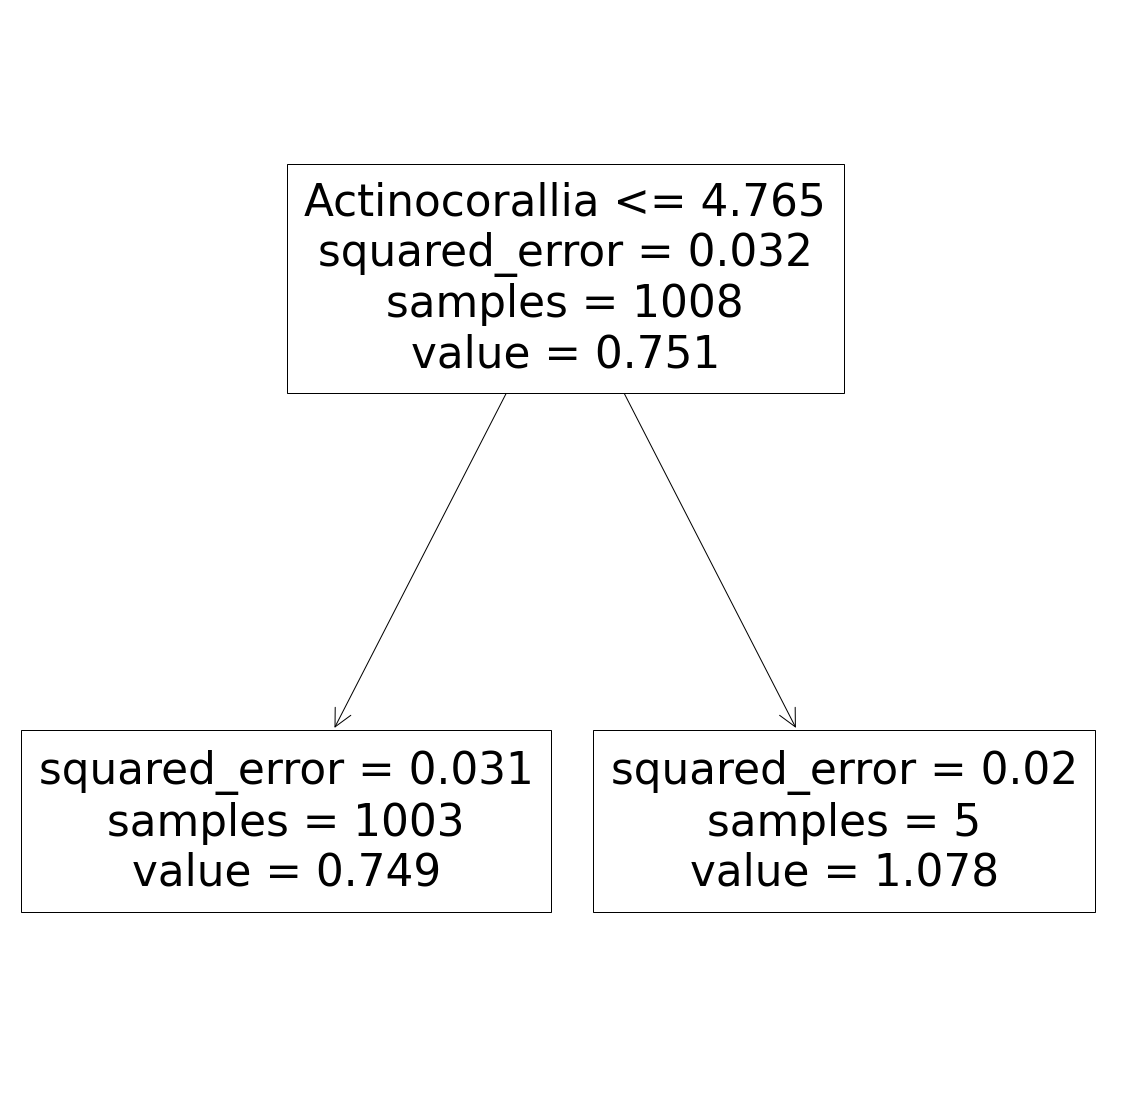

In [ ]:
plt.figure(figsize=(20,20))
plot_tree(small_model, feature_names=['Actinocorallia', 'Clostridium sensu stricto 10', 'Blastocatellaceae'])
plt.show()

####**Exercise: Answer the following questions as a group:**
1. What does each "box" mean?
2. What does each line mean?
3. What does the the first line (with the inequality sign) in each box mean?
4. What do MSE, samples, and value mean?
5. What do you think the very bottom row (the leaves) of your decision tree look like?



In [ ]:
#@title
_1_ = "" #@param {type:"string"}
_2_ = "" #@param {type:"string"}
_3_ = "" #@param {type:"string"}
_4_ = "" #@param {type:"string"}
_5_ = "" #@param {type:"string"}


####**Exercise: Given the decision tree visualization, what do you think ```max_depth=4``` and ```max_leaf_nodes=3``` mean?** What happens if you change those values?


In [ ]:
#@title
max_depth = "" #@param {type:"string"}
max_leaf_nodes = "" #@param {type:"string"}


### Full Model

Let's go ahead and check out the decision tree trained on our full model (without any set values of ```max_depth``` or ```max_leaf_nodes```.

#### **Exercise: Use plot_tree to visualize your full decision tree model.** It should be saved in ```model```, and you can use ```feature_names=X.columns ```.

In [ ]:
plt.figure(figsize=(20,20))
#model = DecisionTreeRegressor()
#model.fit(X_train[['Actinocorallia', 'Clostridium sensu stricto 10', 'Blastocatellaceae']], y_train)
plt.show()

<Figure size 1440x1440 with 0 Axes>

That's a big tree!

###**Exercise: Add in ```max_depth=3``` to the ```plot_tree``` function to just zoom in on the highest level branches to get more detail.**


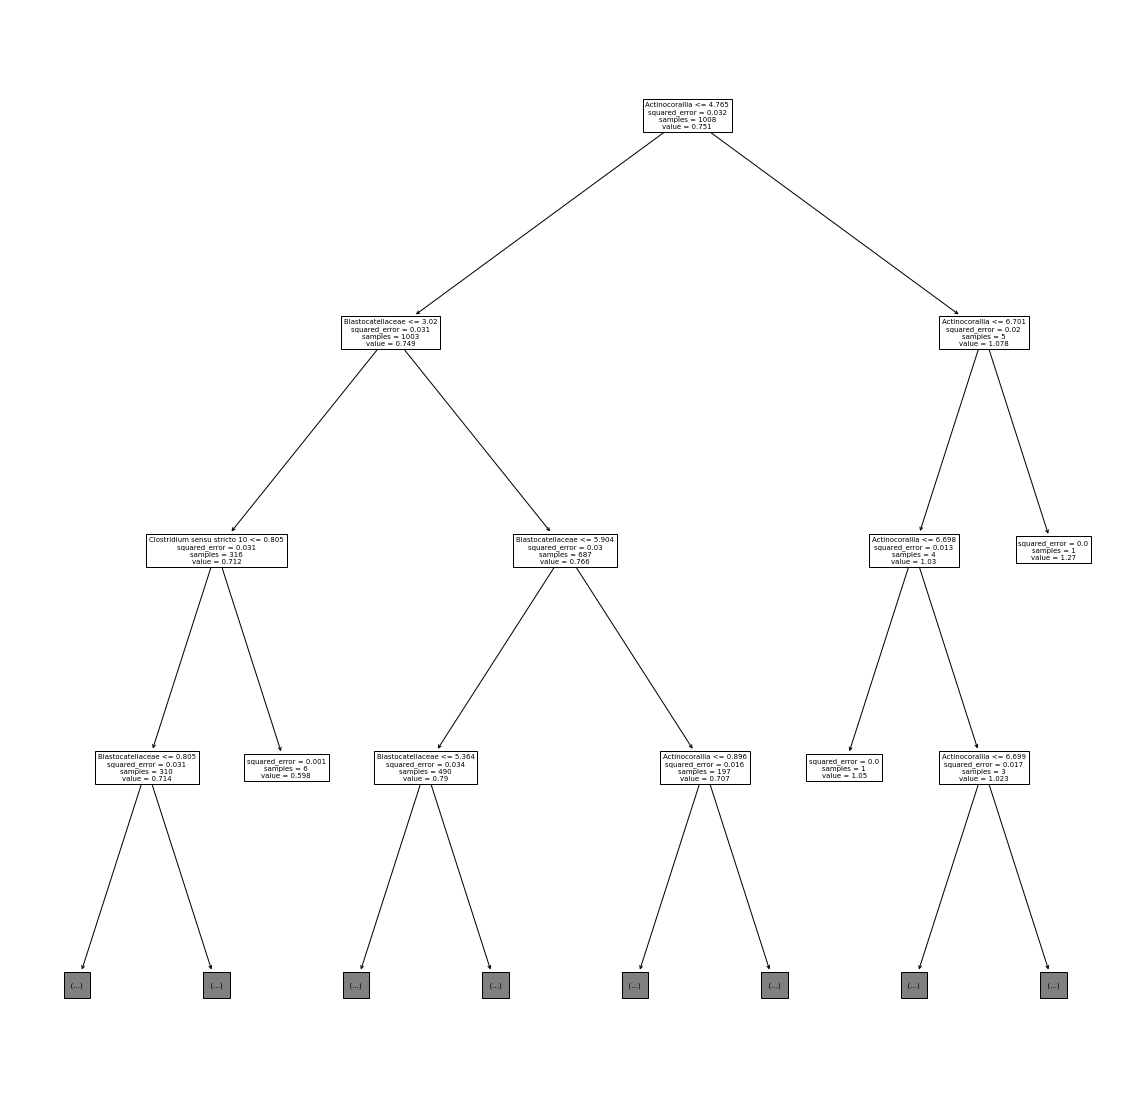

In [ ]:
plt.figure(figsize=(20,20))
plot_tree(model, feature_names= X.columns, max_depth = 3)
plt.show()

Let's try out different values for ```max_depth``` in the cell above!
####**Discuss:** What are some similarities and differences you observe?

## Interpreting Decision Trees

Another way to help us *interpret* the decision tree (or figure out what the decision tree is doing and why) is to see which features were the most important in the model.

### Feature Importances

Recall the equation that linear regression is fitting:

$
Y = \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3 + ...
$

The $\beta$s correspond to the weights of features, or how important each feature is to the model. In decision trees & random forests, we don't fit to a linear equation so we don't have feature weight coefficients per say, but we can calculate something called **feature importances**. Feature importances are similar to weights, in that they have to do with how well a certain feature helped with the prediction.  

We can access the values of the feature importances after training with ```model.feature_importances_```.



####**Exercise: Fill in the code below to organize your feature importances into a nice dataframe.  Go ahead and look at the first *10* rows of the dataframe.**

In [ ]:
## Create a feature_importance dataframe.
feature_importance_dataframe = pd.DataFrame(model.feature_importances_, columns=['feature_importance'])
feature_importance_dataframe.index = X.columns
feature_importance_dataframe.head() # Fill in to check top 10 rows!

ValueError: ignored

#### **Exercise: Fill in the code below to find the top 5 most important features to your model.** Hint: Use the ```.sort_values('feature_importance', ascending=False)``` function to on your ```feature_importance_dataframe``` to sort your data from greatest to least important features, and then use ```.head()``` to see the top 5.

In [ ]:
# Use the .sort_values() function to sort the rows of your dataframe.
feature_importance_dataframe_sorted = feature_importance_dataframe ### FILL IN ###

# Use the .head() function to take a look at the top 5 most important features.
feature_importance_dataframe_sorted ### FILL IN ####

<img src="https://www.growingproduce.com/wp-content/uploads/2016/03/Bacterial-spot-symptoms-on-pepper-leaves-for-web.jpg" width=400>

####**Exercise: Do a quick google search on a couple of the most important bacteria and briefly describe the environments/ecosystems they live in and their function.**

In [ ]:
bacteria_1 = '' #@param {type:"string"}
bacteria_2 = '' #@param {type:"string"}
bacteria_3 = '' #@param {type:"string"}


# Review: Experimenting with Hyperparameters

Let's practice the machine learning pipeline one more time!  Using ```X_train```,  ```X_test```, ``y_train``, and ```y_test``` (these should be already defined for you), (1) build and train a decision tree to predict crop yield from bacterial composition, (2) compute the test predictions and (3) visualize your decision tree.  Try changing different *hyperparameters* of the model such as number of leaves, branches, and splits in your model using the following initialization:

```
model = DecisionTreeRegressor(max_depth=, max_leaf_nodes=)
```



In [ ]:
model = DecisionTreeRegressor()

####**Exercise: Step 1: Train your model**

In [ ]:
# Initialize your model (just use the default settings for now!)
### FILL IN HERE ###

# Train your model with the training data.
### FILL IN HERE ###
model.fit(X_train, y_train)


DecisionTreeRegressor()

####**Exercise: Step 2: Make predictions on your testing data and plot predictions against true crop yields.**

**(Optional):** Can you plot your model's line of best fit to see how closely
predictions matched yields?

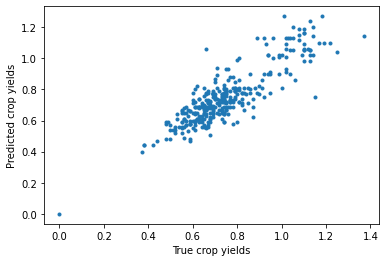

In [ ]:
# Make predictions on your test data. (Don't try to compute accuracy just yet...)
### FILL IN HERE ###
pred = model.predict(X_test)
# Plot your predictions against the true crop yields of the test data.
### FILL IN HERE ###
plt.plot(y_test, pred, ".")
plt.xlabel('True crop yields')
plt.ylabel('Predicted crop yields')
plt.show()

####**Exercise: Step 3: Visualize your decision tree.** Note: It is ok just to look at the first few branches by setting ```max_depth=3``` in ```plot_tree()```.

####**Exercise: Once again, run the following code to plot your predictions against the true crop yields of the test data**

In [ ]:
plt.figure(figsize=(10,10))

# Use plot_tree to visualize the first few branches of your decision tree.
### FILL IN ####


plt.show()


## **Awesome work so far!**
In the next notebook, we will be using our model in order to make policy decisions. So to wrap up, **discuss the following:  Why might we prefer simple machine learning models like decision trees instead of more sophisticated models like neural networks when it comes to policy decisions (lke deciding which areas the government should subsidize for farming?)?**

<img src = "https://media.istockphoto.com/photos/shortcut-from-point-a-to-point-b-concept-picture-id1138022429?k=6&m=1138022429&s=612x612&w=0&h=5t-vKtjIkKqLY9SnRXNdLmR8T-PLzYJTSo1kNrdCnoY=" width=400/>
